In [16]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random
import time
from collections import deque


#### Section 1

number of nodes & edges in citations graph:  2708 5278
number of nodes & edges in facebook graph:  4039 88234
citations graph density:  0.0014399999126942077
facebook graph density:  0.010819963503439287
max degree in citation graph:  168


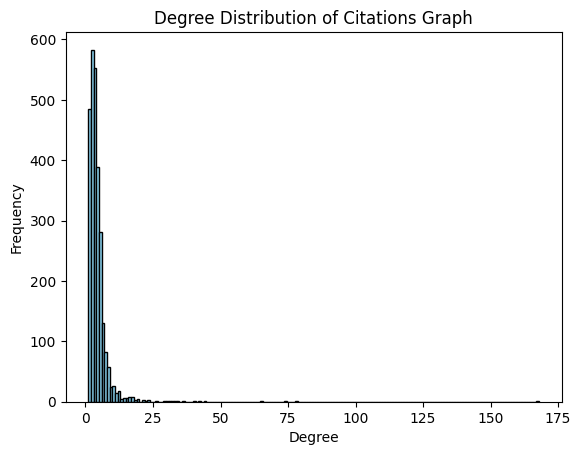

max degree in facebook graph:  1045


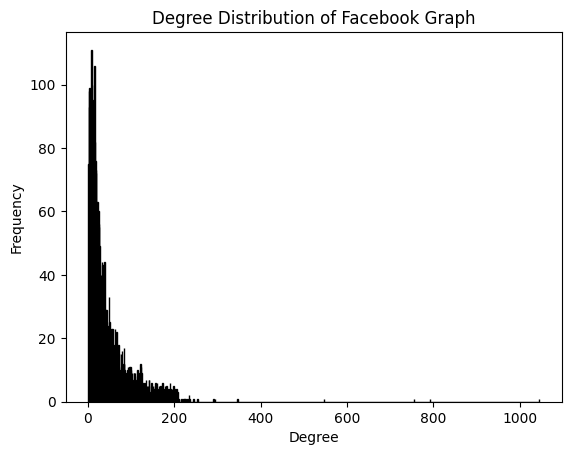

average clustering coefficient of citations graph:  0.2406732985019372
average clustering coefficient of facebook graph:  0.6055467186200876
average shortest path length in largest connected component of citations graph 6.310998681298742
average shortest path length in largest connected component of facebook graph 3.6925068496963913
degree assortativity coefficient of citations graph:  -0.06587087427227857
degree assortativity coefficient of facebook graph:  0.06357722918564943
number of connected components of citations graph:  78
number of connected components of facebook graph:  1
Size of giant component citations graph: 2485 (91.77% of all nodes)
Size of giant component in facebook graph: 4039 (100.00% of all nodes)


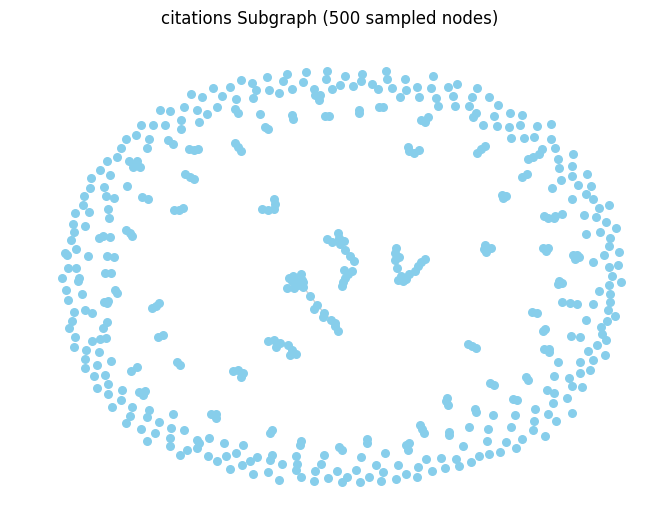

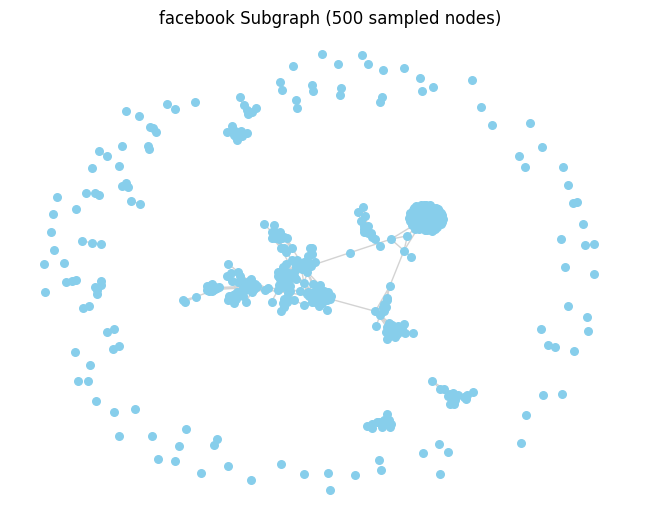

In [3]:
citations_graph= nx.read_edgelist("./cora.cites", delimiter=None, nodetype=int, create_using=nx.Graph()) # I consider citations graph as an undirected graph
facebook_graph=nx.read_edgelist("./facebook_combined.txt", delimiter=" ", nodetype=int, create_using=nx.Graph())

print('number of nodes & edges in citations graph: ',citations_graph.number_of_nodes(),citations_graph.number_of_edges())
print('number of nodes & edges in facebook graph: ',facebook_graph.number_of_nodes(),facebook_graph.number_of_edges())
print('citations graph density: ' , nx.density(citations_graph)) # density of adjacency matrix of graph: density in real world graphs is low
print('facebook graph density: ',nx.density(facebook_graph))

# degree distribution
degrees = [d for _, d in citations_graph.degree()]
print('max degree in citation graph: ',max(degrees))
plt.hist(degrees, bins=max(degrees), color='skyblue', edgecolor='black')
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution of Citations Graph")
plt.show()


degrees = [d for _, d in facebook_graph.degree()]
print('max degree in facebook graph: ',max(degrees))
plt.hist(degrees, bins=max(degrees), color='skyblue', edgecolor='black')
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution of Facebook Graph")
plt.show()

# clustering coefficient
print('average clustering coefficient of citations graph: ',nx.average_clustering(citations_graph))
print('average clustering coefficient of facebook graph: ',nx.average_clustering(facebook_graph))

# average shortest path length is largest connected component
largest_connected_component = max(nx.connected_components(citations_graph), key=len)
G_sub = citations_graph.subgraph(largest_connected_component)
print('average shortest path length in largest connected component of citations graph',nx.average_shortest_path_length(G_sub))

largest_connected_component = max(nx.connected_components(facebook_graph), key=len)
G_sub = facebook_graph.subgraph(largest_connected_component)
print('average shortest path length in largest connected component of facebook graph',nx.average_shortest_path_length(G_sub))


# degree correlation = Similarity in the degree of nodes that are connected to each other
print('degree assortativity coefficient of citations graph: ',nx.degree_assortativity_coefficient(citations_graph))
print('degree assortativity coefficient of facebook graph: ',nx.degree_assortativity_coefficient(facebook_graph))

# number of connected components
print('number of connected components of citations graph: ',nx.number_connected_components(citations_graph))
print('number of connected components of facebook graph: ',nx.number_connected_components(facebook_graph))

# existence of giant component
components = sorted(nx.connected_components(citations_graph), key=len, reverse=True)
largest_connected_component = components[0]
print(f"Size of giant component citations graph: {len(largest_connected_component)} ({len(largest_connected_component)/citations_graph.number_of_nodes():.2%} of all nodes)")

components = sorted(nx.connected_components(facebook_graph), key=len, reverse=True)
largest_connected_component = components[0]
print(f"Size of giant component in facebook graph: {len(largest_connected_component)} ({len(largest_connected_component)/facebook_graph.number_of_nodes():.2%} of all nodes)")


# graph pictures
nodes_sample = random.sample(list(citations_graph.nodes()), 500)
G_sub = citations_graph.subgraph(nodes_sample)
nx.draw(G_sub, node_size=30, node_color="skyblue", edge_color="lightgray")
plt.title("citations Subgraph (500 sampled nodes)")
plt.show()

nodes_sample = random.sample(list(facebook_graph.nodes()), 500)
G_sub = facebook_graph.subgraph(nodes_sample)
nx.draw(G_sub, node_size=30, node_color="skyblue", edge_color="lightgray")
plt.title("facebook Subgraph (500 sampled nodes)")
plt.show()

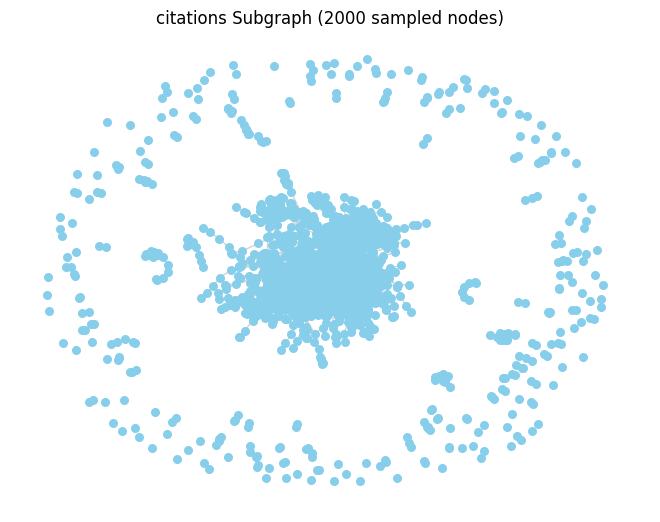

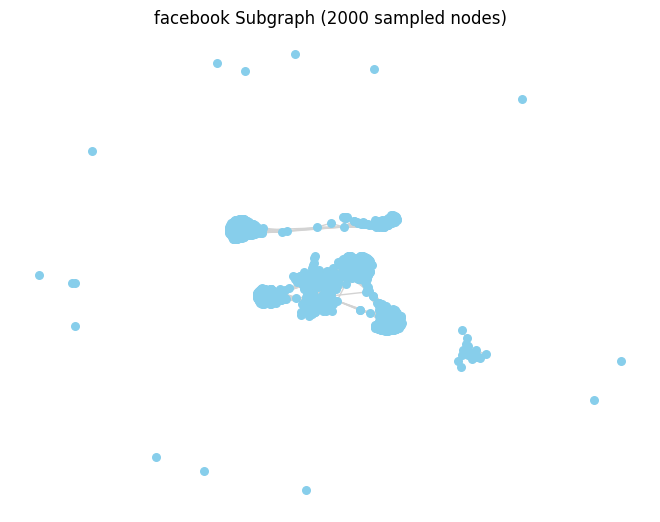

In [4]:
# graph pictures
nodes_sample = random.sample(list(citations_graph.nodes()), 2000)
G_sub = citations_graph.subgraph(nodes_sample)
nx.draw(G_sub, node_size=30, node_color="skyblue", edge_color="lightgray")
plt.title("citations Subgraph (2000 sampled nodes)")
plt.show()

nodes_sample = random.sample(list(facebook_graph.nodes()), 2000)
G_sub = facebook_graph.subgraph(nodes_sample)
nx.draw(G_sub, node_size=30, node_color="skyblue", edge_color="lightgray")
plt.title("facebook Subgraph (2000 sampled nodes)")
plt.show()

##### research guestions:
1. Whether citations graph & facebook graph have small world property or not? yes, they have. because they have large clustering coefficients & small average shortest path length about 6 or 4.
2. Do the degree ditributions of citations graph & facebook graph resemble a power law? yes, they do. looking at the image of the degree distribution, it can be seen that it resembles a power law.

clustering coefficient & average shortest path length are chosen for responding to question 1 and degree ditribution for responding to question2.

My expectations regarding the distribution of degrees, clustering coefficient, average shortest path length, and the presence of giant components were corespond to the calculated results.

The negative degree correlation value in the citations graph indicates that in this network, nodes with high degree are usually connected to nodes with low degree, but the positive correlation in the Facebook network indicates that nodes with high degree are well connected to each other.




#### Section 2

number of edges in facebook graph is:  88234
number of edges in erdos-renyi model of facebook graph is:  88662


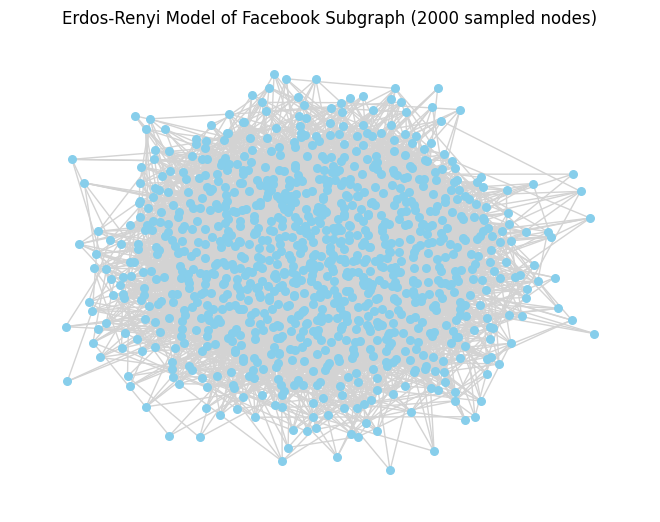

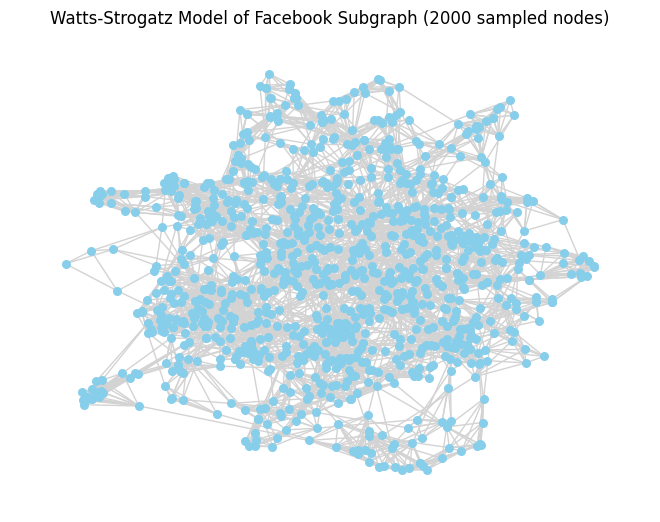

max degree in erdos-renyi graph:  72


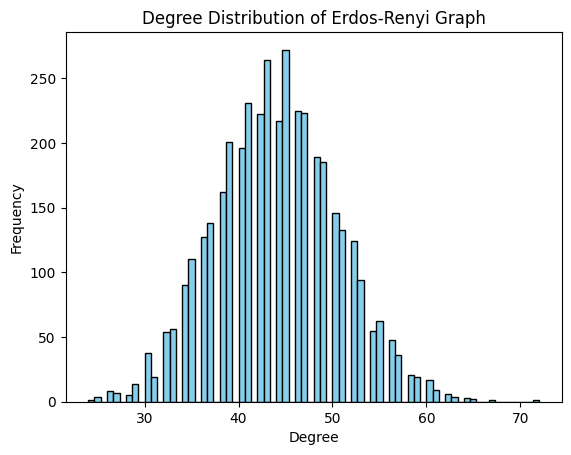

max degree in watts-strogatz graph:  49


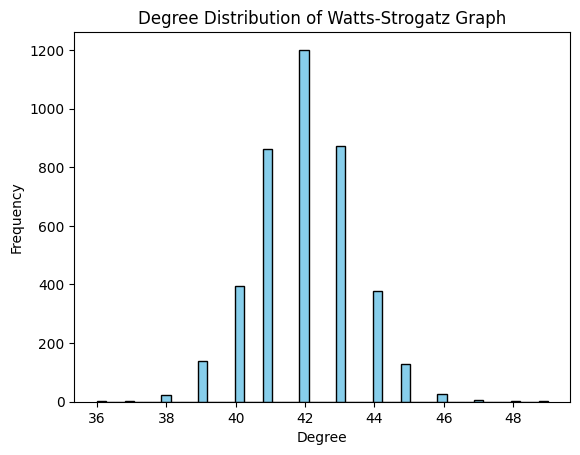

max degree in facebook graph:  1045


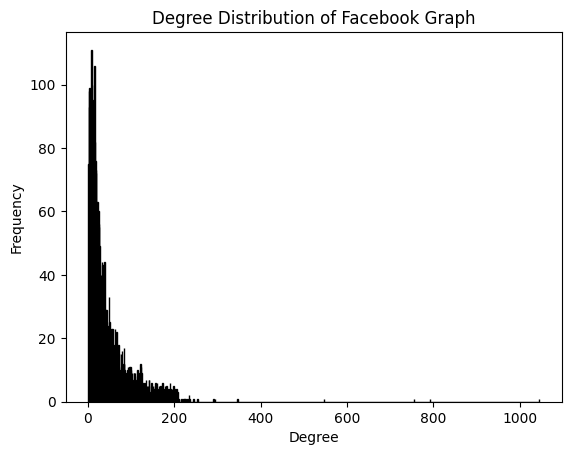

average clustering coefficient of Erdos-Renyi graph:  0.010849948436296032
average clustering coefficient of Watts-Strogatz graph:  0.626026542514733
average clustering coefficient of Facebook graph:  0.6055467186200876
average shortest path length in largest connected component of Erdos-Renyi graph 2.602767641547414
average shortest path length in largest connected component of Watts-Strogatz graph 3.264294230803897
average shortest path length in largest connected component of Facebook graph 3.6925068496963913


In [5]:
# erdos-renyi & watts-strogatz models of facebook graph
n = facebook_graph.number_of_nodes()
m = facebook_graph.number_of_edges()
p = 2 * m / (n * (n - 1)) # if we want G(n,p) have m eadges(roughly) p must be devision of m and n choose 2
G_er = nx.erdos_renyi_graph(n, p)
print('number of edges in facebook graph is: ', facebook_graph.number_of_edges())
print('number of edges in erdos-renyi model of facebook graph is: ', G_er.number_of_edges())

k = int(2 * m / n) # if we want equal average degree in both facebook graph & watts strogatz graph, k must be 2m/n(average degree in facebook graph)
p_rewire = 0.05  # typical small-world rewiring probability
G_ws = nx.watts_strogatz_graph(n, k, p_rewire)

nodes_sample = random.sample(list(G_er.nodes()), 1000)
G_sub = G_er.subgraph(nodes_sample)
nx.draw(G_sub, node_size=30, node_color="skyblue", edge_color="lightgray")
plt.title("Erdos-Renyi Model of Facebook Subgraph (2000 sampled nodes)")
plt.show()

nodes_sample = random.sample(list(G_ws.nodes()), 1000)
G_sub = G_ws.subgraph(nodes_sample)
nx.draw(G_sub, node_size=30, node_color="skyblue", edge_color="lightgray")
plt.title("Watts-Strogatz Model of Facebook Subgraph (2000 sampled nodes)")
plt.show()


# comparing networks
# degree distribution
degrees = [d for _, d in G_er.degree()]
print('max degree in erdos-renyi graph: ',max(degrees))
plt.hist(degrees, bins=max(degrees), color='skyblue', edgecolor='black')
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution of Erdos-Renyi Graph")
plt.show()


degrees = [d for _, d in G_ws.degree()]
print('max degree in watts-strogatz graph: ',max(degrees))
plt.hist(degrees, bins=max(degrees), color='skyblue', edgecolor='black')
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution of Watts-Strogatz Graph")
plt.show()


degrees = [d for _, d in facebook_graph.degree()]
print('max degree in facebook graph: ',max(degrees))
plt.hist(degrees, bins=max(degrees), color='skyblue', edgecolor='black')
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution of Facebook Graph")
plt.show()

# clustering coefficient
print('average clustering coefficient of Erdos-Renyi graph: ',nx.average_clustering(G_er))
print('average clustering coefficient of Watts-Strogatz graph: ',nx.average_clustering(G_ws))
print('average clustering coefficient of Facebook graph: ',nx.average_clustering(facebook_graph))

# average shortest path length is largest connected component
largest_connected_component = max(nx.connected_components(G_er), key=len)
G_sub = G_er.subgraph(largest_connected_component)
print('average shortest path length in largest connected component of Erdos-Renyi graph',nx.average_shortest_path_length(G_sub))

largest_connected_component = max(nx.connected_components(G_ws), key=len)
G_sub = G_ws.subgraph(largest_connected_component)
print('average shortest path length in largest connected component of Watts-Strogatz graph',nx.average_shortest_path_length(G_sub))

largest_connected_component = max(nx.connected_components(facebook_graph), key=len)
G_sub = facebook_graph.subgraph(largest_connected_component)
print('average shortest path length in largest connected component of Facebook graph',nx.average_shortest_path_length(G_sub))



degree ditribution in erdos-renyi and watts-strogatz with small p models are binomial ditributions but in facebook degree distribution is skewed.
degree distribution in watts-strogatz model depends on rewiring propability p. if p is small and we have a small world model degree distribution is like normal distribution.

average clustering coefficient in erdos-renyie model is less than watts-strogatz and facebook models and in watts-strogatz and facebook models we have almost equal clustering coefficients.

average shortest path length in erdos-renyi model is less than watts-strogatz and facebook models due to its greater randomness & lower clustering coefficient but average shortest path length is almost equal in both facebook and watts-strogatz models.

In [7]:
def find_best_p(G_real, model, p_values):

    # real network metrics
    clustering_real = nx.average_clustering(G_real)
    largest_connected_component = max(nx.connected_components(G_real), key=len)
    G_real_sub = G_real.subgraph(largest_connected_component)
    path_real = nx.average_shortest_path_length(G_real_sub)

    best_p, best_err, best_vals = None, float('inf'), None
    n = G_real.number_of_nodes()
    m = G_real.number_of_edges()

    for p in p_values:
        if model == "ER":
            G_model = nx.erdos_renyi_graph(n, p)
        elif model == "WS":
            k = int(2 * m / n)
            G_model = nx.watts_strogatz_graph(n, k, p)

    
        largest_connected_component = max(nx.connected_components(G_model), key=len)
        G_sub = G_model.subgraph(largest_connected_component)
        path_model = nx.average_shortest_path_length(G_sub)

        clustering_model = nx.average_clustering(G_model)

        # Error metric
        err = abs(clustering_model - clustering_real) + abs(path_model - path_real)
        print(f"{model} p={p:.3f}: clustering={clustering_model:.4f}, path={path_model:.4f}, error={err:.4f}")

        if err < best_err:
            best_err = err
            best_p = p
            best_vals = (clustering_model, path_model)

    print("Best match:")
    print(f"Model={model}, p={best_p:.3f}, clustering={best_vals[0]:.4f}, path={best_vals[1]:.4f}, total error={best_err:.4f}")
    return best_p, best_vals


best_p_er, vals_er = find_best_p(facebook_graph, model="ER", p_values=np.linspace(0.05, 0.7, 5))
best_p_ws, vals_ws = find_best_p(facebook_graph, model="WS", p_values=np.linspace(0.001, 0.5, 5))


ER p=0.050: clustering=0.0499, path=1.9501, error=2.2981
ER p=0.212: clustering=0.2125, path=1.7875, error=2.2981
ER p=0.375: clustering=0.3748, path=1.6251, error=2.2981
ER p=0.537: clustering=0.5375, path=1.4625, error=2.2981
ER p=0.700: clustering=0.6999, path=1.3001, error=2.4867
Best match:
Model=ER, p=0.212, clustering=0.2125, path=1.7875, total error=2.2981
WS p=0.001: clustering=0.7293, path=7.1033, error=3.5345
WS p=0.126: clustering=0.4954, path=2.9422, error=0.8604
WS p=0.251: clustering=0.3128, path=2.8000, error=1.1853
WS p=0.375: clustering=0.1839, path=2.7379, error=1.3762
WS p=0.500: clustering=0.0999, path=2.6940, error=1.5042
Best match:
Model=WS, p=0.126, clustering=0.4954, path=2.9422, total error=0.8604



in erdos-renyi model clustering coefficient increase and average shortest path length decrease when we increase p. for a clustering coefficient similar to facebook graph we must choose p=0.6 (because average clustering coefficient in erdos-renyi model is equal to p) but in this setting we will have an average shortest path length much less than facebook graph average shortest path length. therefore in erdos-renyi model we cann't match both of these metrics with real world networks like facebook graph, but in watts–strogatz model, when p was between 0.01 and 0.1, both clustering coefficient and average shortest path length were close to those of the real world network and watts-strogatz better models real world networks because it can have same clustering coefficient & average shortest path length as real world networks have.


#### Section 3

In [15]:
def kleinberg_graph(n, r, long_range_per_node):
   
    G = nx.grid_2d_graph(n, n, create_using=nx.DiGraph()) # in kleinberg model edges especially long-range edges are directed
    nodes = list(G.nodes())

    for u in nodes:
        distances = {v: abs(u[0] - v[0]) + abs(u[1] - v[1]) for v in nodes if v != u} # in kleinberg model we must use nodes distance on lattice which in a 2D lattice is equal to manhattan distance
        weights = np.array([float(d) ** (-r) if d > 0 else 0 for d in distances.values()])
        weights /= weights.sum()

        targets = random.choices(list(distances.keys()), weights=weights, k=long_range_per_node)

        local_neighbors = list(G.neighbors(u))
        if local_neighbors:
            to_remove = random.choice(local_neighbors)
            # if G.has_edge(u, to_remove):
            G.remove_edge(u, to_remove)
        for v in targets:
            G.add_edge(u, v)

    return G


def greedy_search(G, start, target, mode="distance"): # we can choose closest neighbor to the target or neighbor with highest degree depend on search mode.
    current = start
    visited = set([current])
    steps = 0

    while current != target and steps < len(G):
        neighbors = list(G.neighbors(current))
        if not neighbors:
            break

        if mode == "distance":
            current = min(neighbors, key=lambda x: abs(x[0]-target[0]) + abs(x[1]-target[1]))
        elif mode == "degree":
            current = max(neighbors, key=lambda x: G.degree(x))

        visited.add(current)
        steps += 1

    return steps, current == target


def test_kleinberg(r_values, n, trials, mode="distance"):
    results = []
    print(f"Running Kleinberg search in mode='{mode}'")
    for r in r_values:
        G = kleinberg_graph(n, r,1)
        total_steps, success = 0, 0
        t0 = time.time()
        for _ in range(trials):
            s = (0, 0)
            t = (n-1, n-1)
            steps, ok = greedy_search(G, s, t, mode=mode)
            total_steps += steps
            success += int(ok)
        t1 = time.time()
        avg_steps = total_steps / trials
        success_rate = success / trials
        avg_time = (t1 - t0) / trials
        results.append((r, avg_steps, success_rate, avg_time))
        print(f"r={r}: avg_steps={avg_steps:.2f}, success={success_rate:.2f}, time={avg_time:.4f}s")
    return results


r_values = [0,1,2,3]
results_distance = test_kleinberg(r_values, n=100, trials=5, mode="distance")
# results_degree   = test_kleinberg(r_values, n=100, trials=5, mode="degree")



Running Kleinberg search in mode='distance'
r=0: avg_steps=10000.00, success=0.00, time=0.0115s
r=1: avg_steps=13.00, success=1.00, time=0.0000s
r=2: avg_steps=10000.00, success=0.00, time=0.0120s
r=3: avg_steps=10000.00, success=0.00, time=0.0104s


we have a 2D grid. 
when r is 0, long range links are quite random and we have watts-strogatz model.
when r is 3, long range links are connected to local nodes because probability of connecting source node to a far node with a long range link is very low due to third power of nodes distance in denominator of fraction.
in multiple execution of above code I see that r=1 and r=2 were good and had shorter path length between source and target nodes.
kleinberg theory says the appropriate value of r is approximately equal to the lattice dimensions.

#### Section 4

Source node: 352
Target nodes (increasing distance): [1882, 587, 3851, 856, 846]
Target 1882: distance=2, time=0.001215 s
Target 587: distance=3, time=0.003177 s
Target 3851: distance=4, time=0.003716 s
Target 856: distance=5, time=0.007583 s
Target 846: distance=6, time=0.009148 s


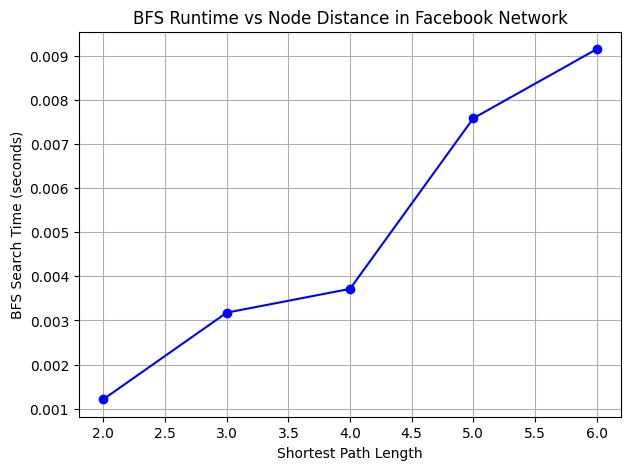


Correlation between path length and BFS runtime: 0.976


In [32]:
# distance between two nodes
def bfs(G, start, target):
    visited = set([start])
    queue = deque([(start, 0)])
    t0 = time.time()
    while queue:
        node, depth = queue.popleft()
        if node == target:
            t1 = time.time()
            return depth, (t1 - t0)
        for neighbor in G.neighbors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, depth + 1))
    t1 = time.time()
    return None, (t1 - t0)

facebook_graph=nx.read_edgelist("./facebook_combined.txt", delimiter=" ", nodetype=int, create_using=nx.Graph())

nodes = list(facebook_graph.nodes())

# Pick a source node
source = random.choice(nodes)
# Compute shortest paths from the source to all reachable nodes
shortest_paths = nx.single_source_shortest_path_length(facebook_graph, source)
# Select nodes with different distances
target_nodes = []
for d in range(2, 100):  # distances between 2 and 7 hops
    far_nodes = [n for n, dist in shortest_paths.items() if dist == d]
    if far_nodes:
        target_nodes.append(random.choice(far_nodes))

print(f"Source node: {source}")
print(f"Target nodes (increasing distance): {target_nodes}")


distances = []
times = []

for t in target_nodes:
    path_length, elapsed = bfs(facebook_graph, source, t)
    if path_length is not None:
        distances.append(path_length)
        times.append(elapsed)
        print(f"Target {t}: distance={path_length}, time={elapsed:.6f} s")


plt.figure(figsize=(7,5))
plt.plot(distances, times, 'o-', color='blue')
plt.xlabel("Shortest Path Length")
plt.ylabel("BFS Search Time (seconds)")
plt.title("BFS Runtime vs Node Distance in Facebook Network")
plt.grid(True)
plt.show()

if len(distances) > 1:
    corr = np.corrcoef(distances, times)[0,1]
    print(f"\nCorrelation between path length and BFS runtime: {corr:.3f}")


#### Section 5

*question 1:*

real world networks have high clustering coefficient because nodes are similar in some features usually make groups with each other, but they have high search capability because they have not random long range edges. these long range links or weak ties cause to short path length between nodes despite the high clustering coefficient of the network and this fact that these link are not random makes the network searchable in a reasonable amount of time.

*question 2:*

watts-strogatz can model high clustering coefficient and low diameter of network but it can not make searchable networks (in a reasonable time). beacause long range links are random.

*question 3:*

in kleinberg model probability of connecting two nodes is inversely related to their distance, so we can find a decentralized search algorithm with O((log n)^2) time complexity for finding path between nodes. so this model has clustering coefficient & average shortest path length similar to real graphs and also it is searchable. 

*question 4:*

if the network has small diameter and nodes with high degree (hubs) and small world property, search on the network has less time complexity. if the network has high clustering coefficient without long range links the time complexity of searching on the network increases.  

